--- First 5 Rows ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

--- Missing Values Check ---
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

--- Data Insights ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null 

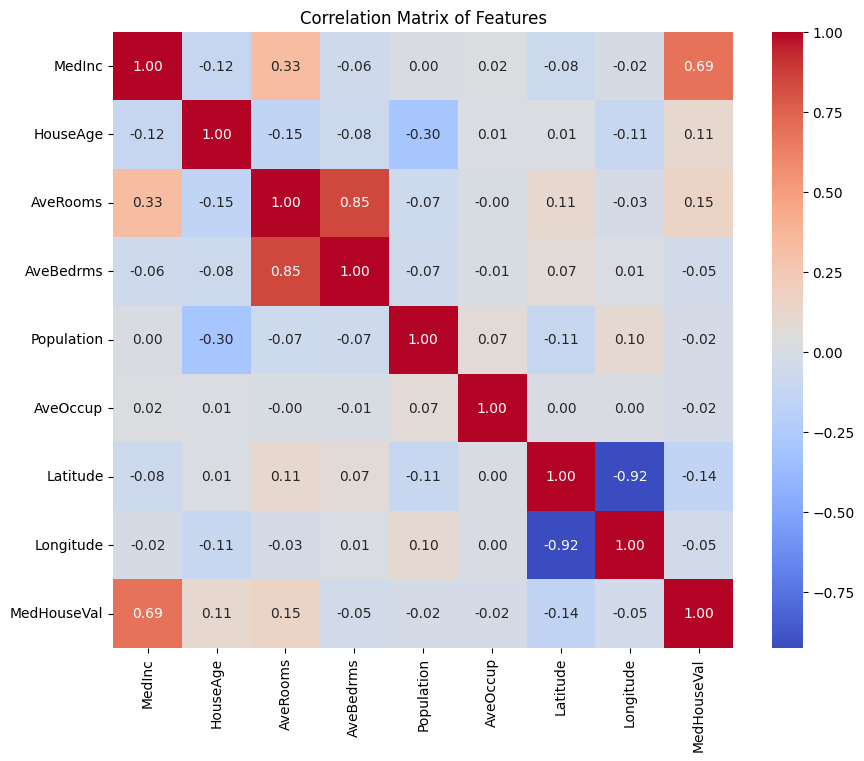


=== Model Performance ===
MAE:  0.533
RMSE: 0.746
R2:   0.576


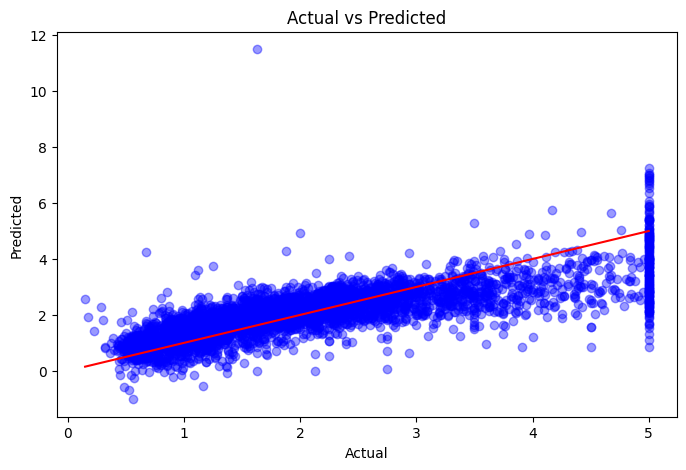

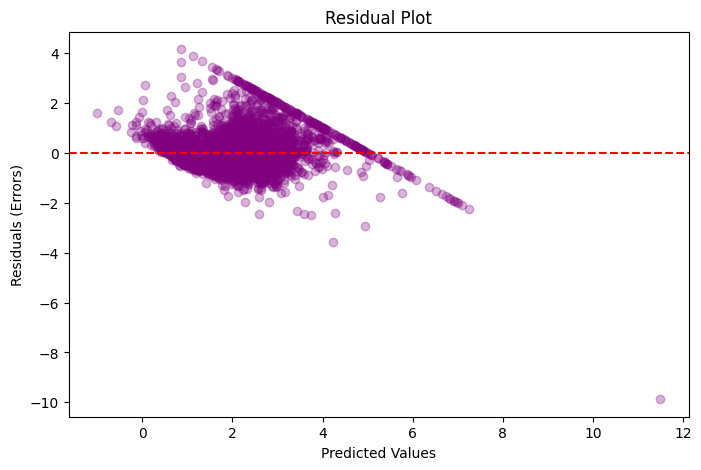

In [9]:
# ==========================================
# 1. IMPORT LIBRARIES & LOAD DATA
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Fetch the dataset correctly
housing_data = fetch_california_housing(as_frame=True)
df = pd.concat([housing_data.data, housing_data.target.rename('MedHouseVal')], axis=1)

# Quick look at the data
print("--- First 5 Rows ---")
print(df.head())

# ==========================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
print("\n--- Missing Values Check ---")
print(df.isnull().sum())  # Check for missing values

# Basic data structure and statistics
print("\n--- Data Insights ---")
df.info()

# Correlation Matrix (To see how features relate to house values)
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Features")
plt.show()

# ==========================================
# 3. SPLIT DATA INTO TRAIN/TEST SETS
# ==========================================
# Target (y) is 'MedHouseVal', Features (X) is everything else
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 4. TRAIN THE LINEAR REGRESSION MODEL
# ==========================================
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# ==========================================
# ==========================================
# 5. EVALUATE THE MODEL (Cleaned & Updated)
# ==========================================
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Printed output
print("\n=== Model Performance ===")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2:   {r2:.3f}")
# ==========================================
# 6. VISUALIZATION
# ==========================================
# Plot 1: Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.4, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

# Plot 2: Residual Plot (Errors)
plt.figure(figsize=(8, 5))
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.3, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Errors)")
plt.title("Residual Plot")
plt.show()